## Supplementary Fig. 6a

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




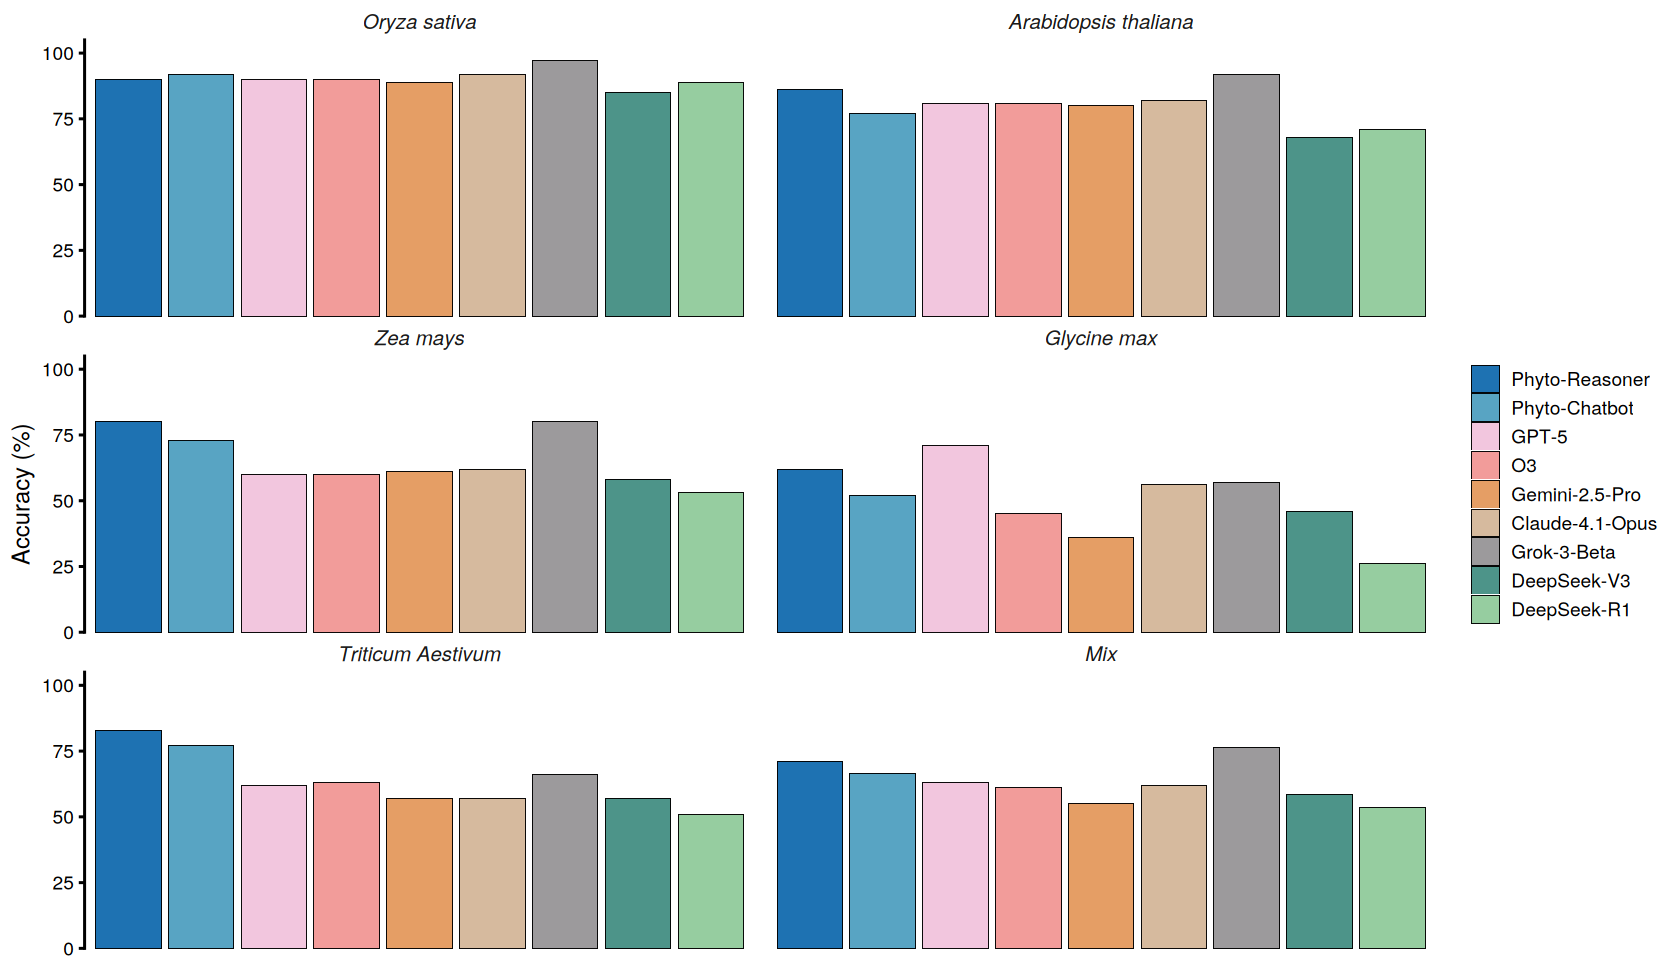

In [1]:
library(tidyverse)
library(ggplot2)
library(scales)

# 1. 内嵌 Figure 4 对应的数据框
df_fig4 <- tibble(
  model = c(
    "Phyto-Chatbot", "Phyto-Reasoner", "Claude-4.1-Opus", 
    "DeepSeek-R1", "DeepSeek-V3", "GPT-5", "Gemini-2.5-Pro", "Grok-3-Beta", "O3"
  ),
  Arabidopsis.thaliana = c(0.77, 0.86, 0.82, 0.71, 0.68, 0.81, 0.80, 0.92, 0.81),
  Oryza.sativa         = c(0.92, 0.90, 0.92, 0.89, 0.85, 0.90, 0.89, 0.97, 0.90),
  Zea.mays             = c(0.73, 0.80, 0.62, 0.53, 0.58, 0.60, 0.61, 0.80, 0.60),
  Glycine.max          = c(0.52, 0.62, 0.56, 0.26, 0.46, 0.71, 0.36, 0.57, 0.45),
  Triticum.Aestivum    = c(0.77, 0.83, 0.57, 0.51, 0.57, 0.62, 0.57, 0.66, 0.63),
  Mix                  = c(0.665, 0.710, 0.620, 0.535, 0.585, 0.630, 0.550, 0.765, 0.610)
)

# 2. 定义配色与排序 (与 Figure 1 使用同一套字典)
color_map_fig4 <- c(
  "Phyto-Reasoner" = "#1e72b2",
  "Phyto-Chatbot"  = "#58A4C3",
  "GPT-5"                            = "#F2C6DE",
  "O3"                               = "#F29C9A",
  "Gemini-2.5-Pro"                   = "#E59E65",
  "Claude-4.1-Opus"                  = "#D6BA9E",
  "Grok-3-Beta"                      = "#9C9A9C",
  "DeepSeek-V3"                      = "#4D9489",
  "DeepSeek-R1"                      = "#96CDA0"
)

order_fig4 <- c(
  "Phyto-Reasoner", "Phyto-Chatbot", "GPT-5", "O3",
  "Gemini-2.5-Pro", "Claude-4.1-Opus", "Grok-3-Beta", "DeepSeek-V3", "DeepSeek-R1"
)

sp_order <- c("Oryza sativa", "Arabidopsis thaliana", "Zea mays",
              "Glycine max", "Triticum Aestivum", "Mix")

# 3. 数据转换：宽表转长表
df_long_fig4 <- df_fig4 %>%
  pivot_longer(
    cols = -model,
    names_to = "type",
    values_to = "TRUE_Ratio"
  ) %>%
  mutate(type = str_replace(type, "\\.", " ")) %>%
  mutate(
    model = factor(model, levels = intersect(order_fig4, unique(model))),
    type  = factor(type, levels = sp_order)
  )

# 4. 执行绘图并设置 Notebook 中显示的尺寸
options(repr.plot.width = 14, repr.plot.height = 8)

p4 <- ggplot(df_long_fig4, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.2) +
  facet_wrap(~type, scales = "free_x", ncol = 2) +
  labs(x = NULL, y = "Accuracy (%)") +
  theme_classic(base_size = 14) +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)),
                     breaks = seq(0, 1, 0.25), 
                     labels = seq(0, 100, 25)) +
  theme(
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(), 
    axis.line.x = element_blank(),  
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    strip.text = element_text(size = 12, face = "italic", margin = margin(b = 5)), 
    strip.background = element_blank(), 
    legend.position = "right",      
    legend.title = element_blank()  
  ) +
  scale_fill_manual(values = color_map_fig4)

# 直接打印显示
p4

## Supplementary Fig. 6b

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Ignoring unknown labels:
• size : "12"
Warning message:
“No shared levels found between `names(values)` of the manual scale an

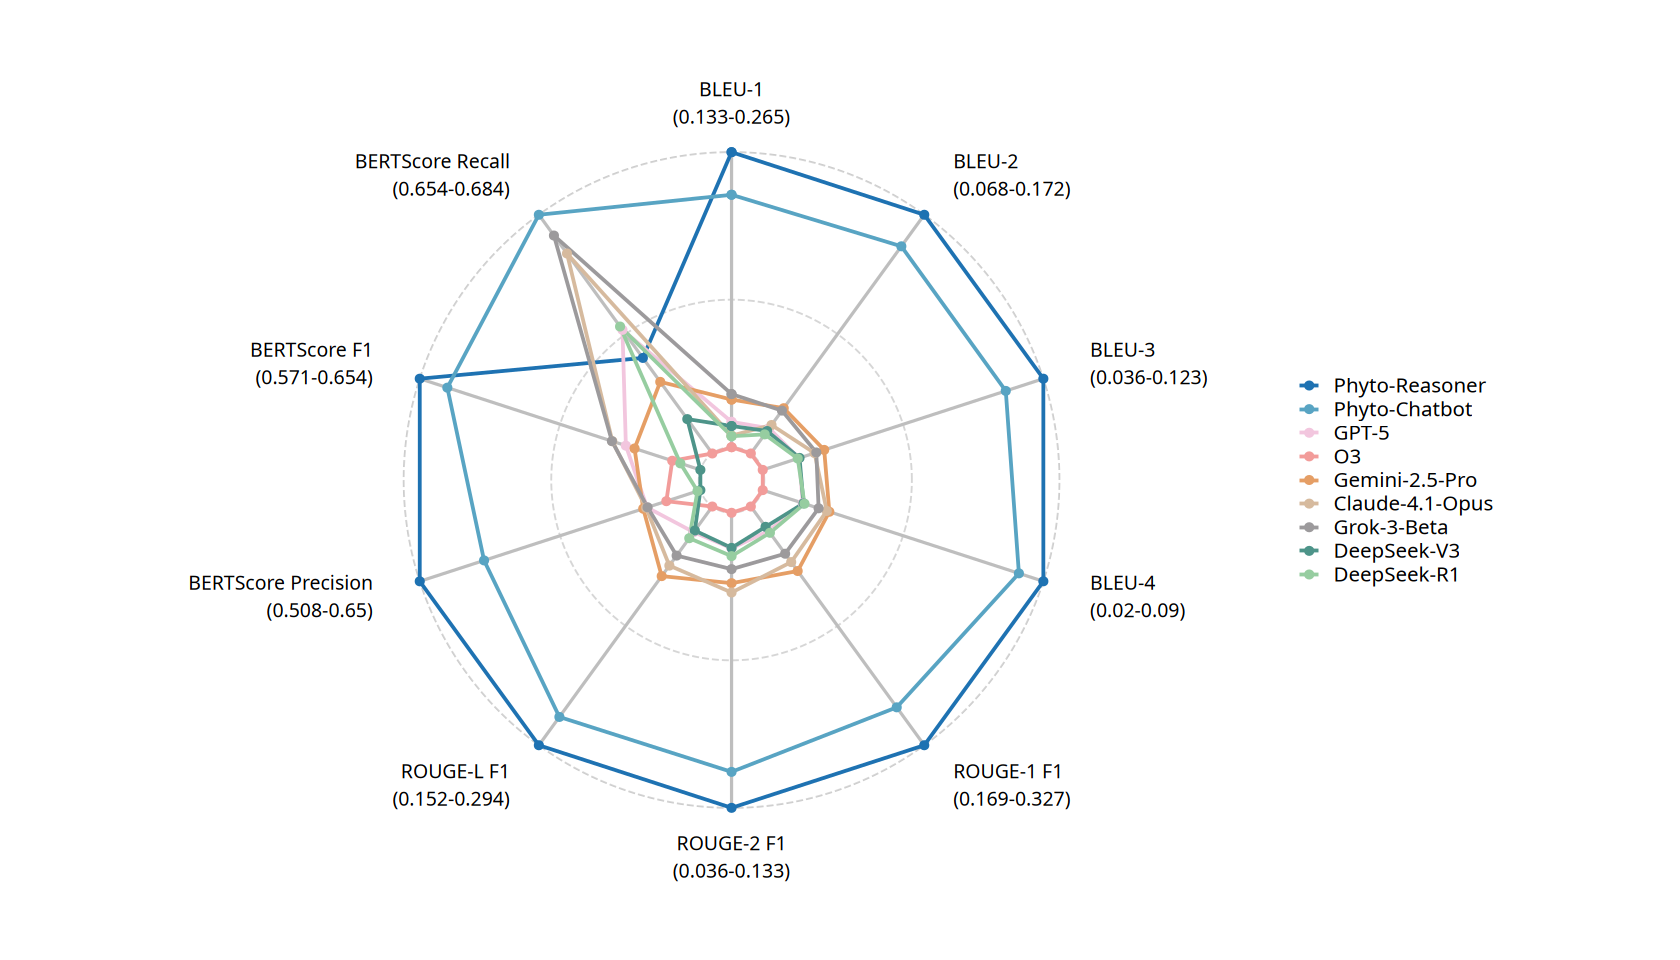

In [1]:
library(tidyverse)
library(ggradar)
library(scales)

# 1. 内嵌 Figure 4 对应的数据框
df_fig4 <- tibble(
  model_name = c(
    "Phyto-Chatbot", "Phyto-Reasoner",
    "DeepSeek-V3", "DeepSeek-R1", "Gemini-2.5-Pro", "GPT-5", "Grok-3-Beta", "O3", "Claude-4.1-Opus"
  ),
  `BLEU-1`              = c(0.24585286, 0.26488576, 0.14256360, 0.13801895, 0.15437427, 0.14444154, 0.15682604, 0.13309703, 0.13826500),
  `BLEU-2`              = c(0.15834360, 0.17205927, 0.07801712, 0.07655490, 0.08794183, 0.07917487, 0.08689271, 0.06825000, 0.08063523),
  `BLEU-3`              = c(0.11160696, 0.12332443, 0.04729955, 0.04674223, 0.05499193, 0.04710658, 0.05253082, 0.03582801, 0.05197854),
  `BLEU-4`              = c(0.084018993, 0.090108939, 0.030377246, 0.030623188, 0.036809539, 0.030211696, 0.034141252, 0.020228216, 0.036176978),
  `ROUGE-1 F1`          = c(0.3016211, 0.3265624, 0.1828402, 0.1867814, 0.2119270, 0.1855757, 0.2005426, 0.1694867, 0.2060477),
  `ROUGE-2 F1`          = c(0.12092842, 0.13274300, 0.04733822, 0.05004636, 0.05893617, 0.04747286, 0.05432215, 0.03580964, 0.06200356),
  `ROUGE-L F1`          = c(0.2775920, 0.2944282, 0.1666209, 0.1711841, 0.1937564, 0.1675687, 0.1815378, 0.1523164, 0.1874841),
  `BERTScore Precision` = c(0.6174101, 0.6500484, 0.5076281, 0.5090854, 0.5366267, 0.5346891, 0.5344251, 0.5248959, 0.5351567),
  `BERTScore F1`        = c(0.6454374, 0.6535978, 0.5705893, 0.5765178, 0.5900596, 0.5926265, 0.5967538, 0.5789100, 0.5966315),
  `BERTScore Recall`    = c(0.6843009, 0.6664104, 0.6587660, 0.6703330, 0.6634196, 0.6699208, 0.6817061, 0.6544695, 0.6794631)
)

# 2. 定义配色与排序
color_map_fig4 <- c(
  "Phyto-Reasoner" = "#1e72b2",
  "Phyto-Chatbot"  = "#58A4C3",
  "GPT-5"                            = "#F2C6DE",
  "O3"                               = "#F29C9A",
  "Gemini-2.5-Pro"                   = "#E59E65",
  "Claude-4.1-Opus"                  = "#D6BA9E",
  "Grok-3-Beta"                      = "#9C9A9C",
  "DeepSeek-V3"                      = "#4D9489",
  "DeepSeek-R1"                      = "#96CDA0"
)

order_fig4 <- c(
  "Phyto-Reasoner", "Phyto-Chatbot", "GPT-5", "O3",
  "Gemini-2.5-Pro", "Claude-4.1-Opus", "Grok-3-Beta", "DeepSeek-V3", "DeepSeek-R1"
)

# 3. 准备雷达图数据与极值计算
plot_data <- df_fig4 %>% rename(group = model_name)

range_labels <- plot_data %>%
  select(-group) %>%
  summarise(across(everything(), list(min = ~min(.), max = ~max(.)))) %>%
  pivot_longer(everything(), names_to = c("metric", ".value"), names_sep = "_") %>%
  mutate(label = paste0(metric, "\n(", round(min, 3), "-", round(max, 3), ")"))

metric_names <- colnames(plot_data)[-1]
new_names <- setNames(range_labels$label, range_labels$metric)
colnames(plot_data)[-1] <- new_names[metric_names]

# Min-Max 归一化并锁定因子的顺位
plot_data_norm <- plot_data %>%
  mutate(across(-group, ~ rescale(.))) %>%
  mutate(group = factor(group, levels = intersect(order_fig4, unique(group)))) %>%
  arrange(group)

group_levels <- levels(plot_data_norm$group)
colors_sub <- color_map_fig4[group_levels]

# 4. 执行绘图并调大 Notebook 渲染尺寸
options(repr.plot.width = 14, repr.plot.height = 8)

p4 <- ggradar(
  plot_data_norm,
  group.line.width = 0.8,
  group.point.size = 1.5,
  grid.line.width = 0.4,
  grid.min = 0, grid.mid = 0.5, grid.max = 1,
  background.circle.colour = "white",
  gridline.min.colour = "gray80", gridline.mid.colour = "gray80", gridline.max.colour = "gray80",
  axis.label.size = 4, legend.text.size = 12,            
  values.radar = c("", "", "")      
)

p4$coordinates$clip <- "off"

p4 <- p4 +
  scale_color_manual(values = setNames(colors_sub, group_levels)) +
  scale_fill_manual(values = setNames(colors_sub, group_levels)) +
  theme(
    panel.background = element_rect(fill = "white", colour = NA),
    plot.background = element_rect(fill = "white", colour = NA),
    panel.border = element_blank(),
    axis.line = element_blank(),
    axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12), legend.title = element_blank(),
    legend.key.size = unit(0.5, "cm"), legend.key.height = unit(0.5, "cm"), legend.key.width = unit(0.5, "cm"),
    legend.margin = margin(0, 0, 0, 0), legend.box.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.2, "cm"), legend.direction = "vertical",
    plot.margin = margin(1, 3, 1, 3, "cm")
  )

# 打印图像
p4